In [4]:
# первоначальный взнос (initinal_payment) хорошо ранжирует риск просрочки (delay)

import pandas as pd

df = pd.read_csv('dataset.csv', sep=';')
print(df.head())
print(df.shape)
print(df.info())
print(df.isna().sum())

   application_id     pd  initinal_payment  delay
0               1  0.054             0.290      0
1               2  0.138             0.183      0
2               3  0.135             0.244      0
3               4  0.042             0.271      0
4               5  0.058             0.174      0
(7307, 4)
<class 'pandas.DataFrame'>
RangeIndex: 7307 entries, 0 to 7306
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   application_id    7307 non-null   int64  
 1   pd                7307 non-null   float64
 2   initinal_payment  7307 non-null   float64
 3   delay             7307 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 228.5 KB
None
application_id      0
pd                  0
initinal_payment    0
delay               0
dtype: int64


In [5]:
df.describe()

,application_id,pd,initinal_payment,delay
count,7307.000000,7307.000000,7307.000000,7307.000000
mean,3654.000000,0.053607,0.279208,0.024223
std,2109.493541,0.032504,0.077206,0.153752
min,1.000000,0.000000,0.006000,0.000000
25%,1827.500000,0.031000,0.225000,0.000000
50%,3654.000000,0.045000,0.282000,0.000000
75%,5480.500000,0.065000,0.339000,0.000000
max,7307.000000,0.249000,0.494000,1.000000


In [6]:
df['initinal_payment'].duplicated().sum()

np.int64(6894)

In [7]:
df['delay'].value_counts(normalize=True)

delay
0    0.975777
1    0.024223
Name: proportion, dtype: float64

In [8]:
df[['initinal_payment', 'delay']].corr()

,initinal_payment,delay
initinal_payment,1.000000,-0.102574
delay,-0.102574,1.000000


In [9]:
df['ip_bin'] = pd.qcut(df['initinal_payment'], q=10, duplicates='drop')

In [10]:
bin_stats = df.groupby('ip_bin').agg(
    cnt=('application_id', 'count'),
    min_ip=('initinal_payment', 'min'),
    max_ip=('initinal_payment', 'max'),
    avg_ip=('initinal_payment', 'mean'),
    bad_rate=('delay', 'mean'),
    avg_pd=('pd', 'mean')
).reset_index()

print(bin_stats)

           ip_bin  cnt  min_ip  max_ip    avg_ip  bad_rate    avg_pd
0  (0.005, 0.176]  742   0.006   0.176  0.141562  0.056604  0.073090
1   (0.176, 0.21]  728   0.177   0.210  0.194582  0.049451  0.063640
2   (0.21, 0.236]  723   0.211   0.236  0.224303  0.026279  0.060563
3   (0.236, 0.26]  743   0.237   0.260  0.248454  0.025572  0.055791
4   (0.26, 0.282]  735   0.261   0.282  0.271883  0.020408  0.053189
5  (0.282, 0.305]  719   0.283   0.305  0.293812  0.018081  0.051677
6  (0.305, 0.328]  762   0.306   0.328  0.316795  0.018373  0.048390
7  (0.328, 0.349]  715   0.329   0.349  0.339120  0.016783  0.046122
8  (0.349, 0.377]  730   0.350   0.377  0.362445  0.005479  0.042099
9  (0.377, 0.494]  710   0.378   0.494  0.404465  0.004225  0.040941


Для проверки гипотезы выборка была разбита на 10 бакетов по значению initinal_payment. По каждому бакету был рассчитан фактический уровень просрочки (bad_rate). Результаты показали выраженную обратную зависимость между величиной первоначального взноса и уровнем просрочки: при росте среднего значения ПВ от 14.2% до 40.4% bad_rate снижается с 5.66% до 0.42%. Таким образом, признак initinal_payment обладает хорошей ранжирующей способностью по отношению к риску просрочки.

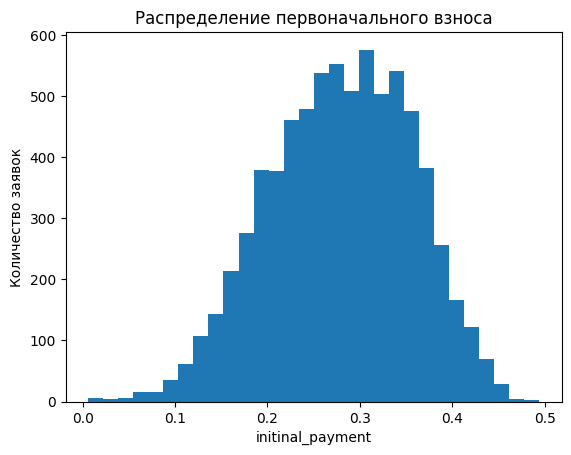

In [11]:
import matplotlib.pyplot as plt

plt.hist(df['initinal_payment'], bins=30)
plt.title('Распределение первоначального взноса')
plt.xlabel('initinal_payment')
plt.ylabel('Количество заявок')
plt.show()

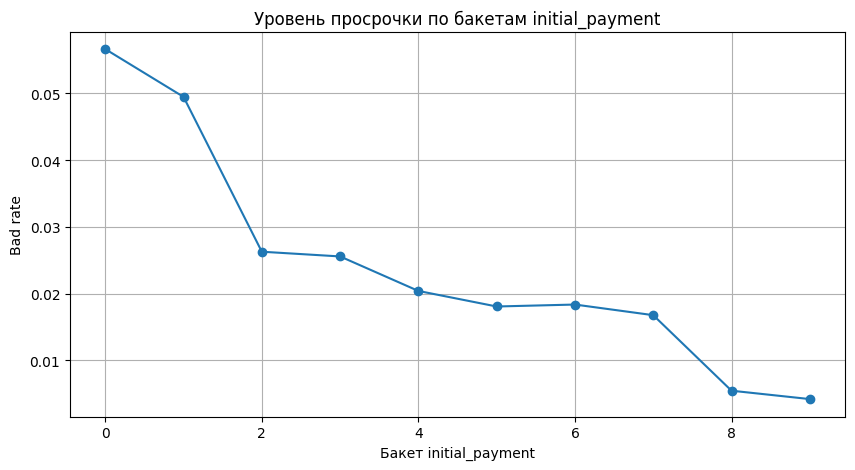

In [12]:
plt.figure(figsize=(10,5))
plt.plot(range(len(bin_stats)), bin_stats['bad_rate'], marker='o')
plt.title('Уровень просрочки по бакетам initial_payment')
plt.xlabel('Бакет initial_payment')
plt.ylabel('Bad rate')
plt.grid(True)
plt.show()

Отношение первоначального взноса к стоимости недвижимости действительно ранжирует уровень просрочки: клиенты с более высоким ПВ в среднем имеют более низкий фактический bad_rate.

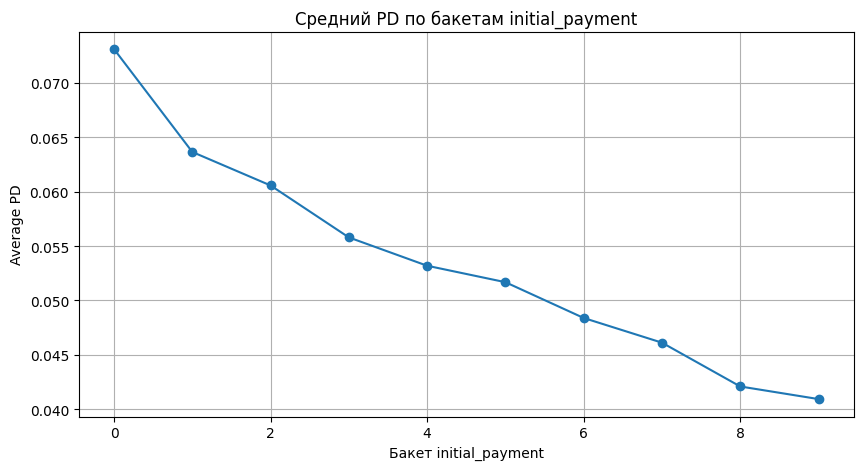

In [13]:
plt.figure(figsize=(10,5))
plt.plot(range(len(bin_stats)), bin_stats['avg_pd'], marker='o')
plt.title('Средний PD по бакетам initial_payment')
plt.xlabel('Бакет initial_payment')
plt.ylabel('Average PD')
plt.grid(True)
plt.show()

Гипотеза подтверждается: признак initinal_payment, который представляет собой отношение первоначального взноса к стоимости недвижимости, демонстрирует хорошую ранжирующую способность по отношению к уровню просрочки. При увеличении ПВ наблюдается устойчивое снижение как фактического bad_rate, так и среднего значения pd.

In [ ]:
thresholds = sorted(df['initinal_payment'].round(3).unique())

rows = []
for t in thresholds:
    subset = df[df['initinal_payment'] >= t]
    if len(subset) == 0:
        continue
    rows.append({
        'threshold': t,
        'cnt': len(subset),
        'share': len(subset) / len(df),
        'bad_rate': subset['delay'].mean(),
        'avg_pd': subset['pd'].mean()
    })

thr_df = pd.DataFrame(rows)

thr_df[thr_df['bad_rate'] <= 0.01]


,threshold,cnt,share,bad_rate,avg_pd
261,0.313,2675,0.366087,0.009720,0.043859
262,0.314,2639,0.361161,0.009852,0.043742
264,0.316,2552,0.349254,0.009796,0.043644
265,0.317,2519,0.344738,0.009131,0.043551
266,0.318,2491,0.340906,0.008832,0.043444
...,...,...,...,...,...
408,0.471,5,0.000684,0.000000,0.020000
409,0.473,4,0.000547,0.000000,0.021750
410,0.479,3,0.000411,0.000000,0.014667
411,0.483,2,0.000274,0.000000,0.013500


Если отбирать клиентов с ПВ примерно от 31.3% и выше, то можно сформировать довольно большой сегмент клиентов - около 35% всей выборки - с фактическим уровнем просрочки около целевых 1%. В качестве порогового значения, на мой взгляд, оптимально выбрать значение 31.6%, так как начиная с этого значения, bad_rate устойчиво падает ниже 1%.

In [15]:
df['pd_bin'] = pd.qcut(df['pd'], q=5, duplicates='drop')
df['ip_group'] = pd.qcut(df['initinal_payment'], q=3, duplicates='drop')

cross_stats = df.groupby(['pd_bin', 'ip_group']).agg(
    cnt=('application_id', 'count'),
    bad_rate=('delay', 'mean')
).reset_index()

print(cross_stats)

             pd_bin        ip_group  cnt  bad_rate
0   (-0.001, 0.029]  (0.005, 0.244]  271  0.022140
1   (-0.001, 0.029]   (0.244, 0.32]  487  0.014374
2   (-0.001, 0.029]   (0.32, 0.494]  780  0.005128
3    (0.029, 0.039]  (0.005, 0.244]  368  0.016304
4    (0.029, 0.039]   (0.244, 0.32]  487  0.016427
5    (0.029, 0.039]   (0.32, 0.494]  559  0.007156
6    (0.039, 0.052]  (0.005, 0.244]  496  0.048387
7    (0.039, 0.052]   (0.244, 0.32]  553  0.018083
8    (0.039, 0.052]   (0.32, 0.494]  454  0.006608
9    (0.052, 0.073]  (0.005, 0.244]  577  0.041594
10   (0.052, 0.073]   (0.244, 0.32]  490  0.014286
11   (0.052, 0.073]   (0.32, 0.494]  365  0.010959
12   (0.073, 0.249]  (0.005, 0.244]  730  0.063014
13   (0.073, 0.249]   (0.244, 0.32]  433  0.041570
14   (0.073, 0.249]   (0.32, 0.494]  257  0.023346


Даже внутри сопоставимых сегментов по pd более высокий ПВ соответствует более низкому bad_rate.